## Andria Linfante
### BINF 5312 Spring 2025
### Term Project - Aspect Mining
Due 4/22/25

### Importing Libraries & Initalize NLP Tools

In [1]:
import pandas as pd
import nltk
import re
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [2]:
pd.set_option('display.width', 180)

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
# Initialize NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

### Load Dataset

In [5]:
df = pd.read_csv('psych_drug_webmd_reviews.csv')
print(df.head(2))

   Unnamed: 0        drug_name       date    age  gender            time_on_drug reviewer_type                      condition  rating_overall  rating_effectiveness  \
0           0  Sertraline Oral  5/12/2024  45-54  Female  1 to less than 2 years       Patient  Posttraumatic Stress Syndrome             5.0                     5   
1           1  Sertraline Oral  4/21/2024  35-44  Female       less than 1 month       Patient                     Depression             1.0                     1   

   rating_ease_of_use  rating_satisfaction                                               text  
0                   5                    5  It's almost two years now and it has been so e...  
1                   1                    1  Iv been on this 4 weeks and iv never felt so a...  


### Preprocessing

In [6]:
# Drop missing values
df = df.dropna(subset=['text'])
# Drop rows with no 'condition'
df = df.loc[(df['condition'] != 'Other') & (df['condition'] != '')]

In [7]:
# Function for text preprocessing
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    # Lemmatization & stopword removal
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [8]:
# Apply preprocessing
df['cleaned_text'] = df['text'].apply(preprocess_text)
df['drug_name_first_word'] = df['drug_name'].str.split().str[0]
df.head(2)

,Unnamed: 0,drug_name,date,age,gender,time_on_drug,reviewer_type,condition,rating_overall,rating_effectiveness,rating_ease_of_use,rating_satisfaction,text,cleaned_text,drug_name_first_word
0,0,Sertraline Oral,5/12/2024,45-54,Female,1 to less than 2 years,Patient,Posttraumatic Stress Syndrome,5.0,5,5,5,It's almost two years now and it has been so e...,almost two year effective havent overthinking ...,Sertraline
1,1,Sertraline Oral,4/21/2024,35-44,Female,less than 1 month,Patient,Depression,1.0,1,1,1,Iv been on this 4 weeks and iv never felt so a...,iv week iv never felt angry irritable stressed...,Sertraline


### Extract Aspects

In [9]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm")

In [45]:
# First several run throughs resulted in mostly comon/generic terms
# I listed the most common generic terms to be removed
generic_terms = set([
    # Pronouns/other
    'i', 'you', 'someone', 'anyone', 'everyone', 'people', 'others', 'that', 'thing', 'something', 'anything', 'everything',

    # Time/dose
    'day', 'week', 'month', 'year', 'time', 'mg', 'mg day', 'night', 'dosage', 'pound', 'mgday',

    # Vague/neutral words
    'life', 'help', 'work', 'sleep', 'bed', 'god', 'problem', 'effect', 'symptom', 'pill', 'nothing', 'u', 'need',

    # Drug names
    'cymbalta', 'lexapro', 'zoloft', 'prozac', 'effexor', 'paxil', 'wellbutrin', 'xanax', 'seroquel', 'alprazolam',

    # Medical
    'medicine', 'medication', 'drug', 'doctor', 'dr', 'doc',
])


In [46]:
def extract_filtered_aspects(text):
    doc = nlp(text)
    aspects = []
    for chunk in doc.noun_chunks:
        phrase = chunk.text.lower().strip()
        if len(phrase.split()) > 1 or phrase not in generic_terms:
            aspects.append(phrase)
    return aspects

In [47]:
# Apply to cleaned text
df['aspects'] = df['cleaned_text'].apply(extract_filtered_aspects)

In [48]:
# Get top aspects
all_aspects = [aspect for sublist in df['aspects'] for aspect in sublist]
top_aspects = Counter(all_aspects).most_common(10)

In [49]:
top_aspects

[('depression', 2086),
 ('anxiety', 1629),
 ('side effect', 1578),
 ('weight', 942),
 ('panic attack', 608),
 ('mood', 553),
 ('weight gain', 424),
 ('mg day', 419),
 ('pain', 396),
 ('headache', 330)]

### Export to CSV

In [59]:
df.to_csv("reviews_with_aspects.csv", index=False)

In [60]:
from google.colab import files
files.download("reviews_with_aspects.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Top 10 Aspects Overall

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

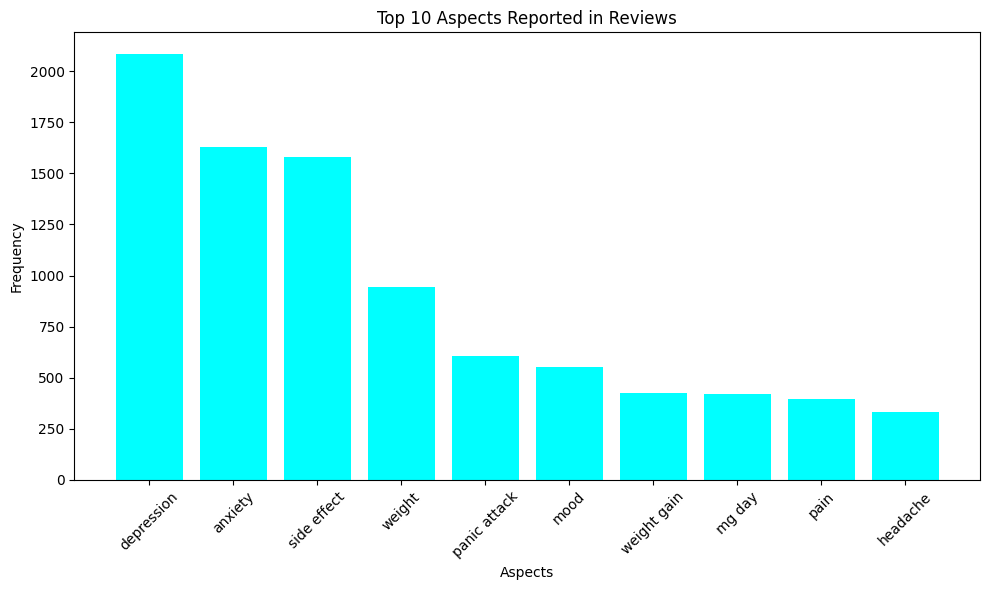

In [51]:
aspect_names, counts = zip(*top_aspects)
plt.figure(figsize=(10, 6))
plt.bar(aspect_names, counts, color='cyan')
plt.title('Top 10 Aspects Reported in Reviews')
plt.xlabel('Aspects')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top Aspects per Top 10 Drug

In [52]:
from collections import Counter

top_10_drugs = df['drug_name_first_word'].value_counts().head(10).index.tolist()

top_df = df[df['drug_name_first_word'].isin(top_10_drugs)]

In [53]:
top_aspects_by_drug = []

for drug in top_10_drugs:
    subset = top_df[top_df['drug_name_first_word'] == drug]
    all_aspects = [aspect for aspects in subset['aspects'] for aspect in aspects]
    common = Counter(all_aspects).most_common(3)
    for aspect, count in common:
        top_aspects_by_drug.append({'drug': drug, 'aspect': aspect, 'count': count})

top_aspects_df = pd.DataFrame(top_aspects_by_drug)

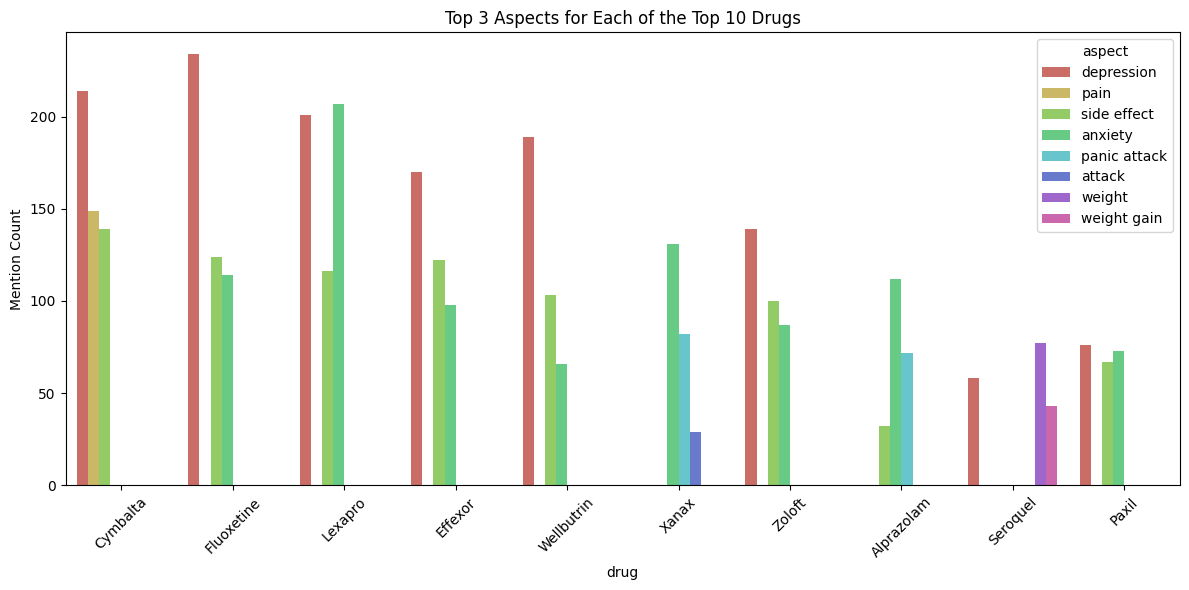

In [54]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_aspects_df,
    x='drug',
    y='count',
    hue='aspect',
    palette='hls'
)
plt.title('Top 3 Aspects for Each of the Top 10 Drugs')
plt.ylabel('Mention Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Prevelence of 'depression' Aspect Over Time

In [55]:
df['date'] = pd.to_datetime(df['date'])

In [56]:
depression_df = df[df['aspects'].apply(lambda x: 'depression' in x)]

In [57]:
depression_df['year'] = depression_df['date'].dt.year
depression_trend = depression_df.groupby('year').size().reset_index(name='count')

<ipython-input-57-8859c905a5f6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  depression_df['year'] = depression_df['date'].dt.year


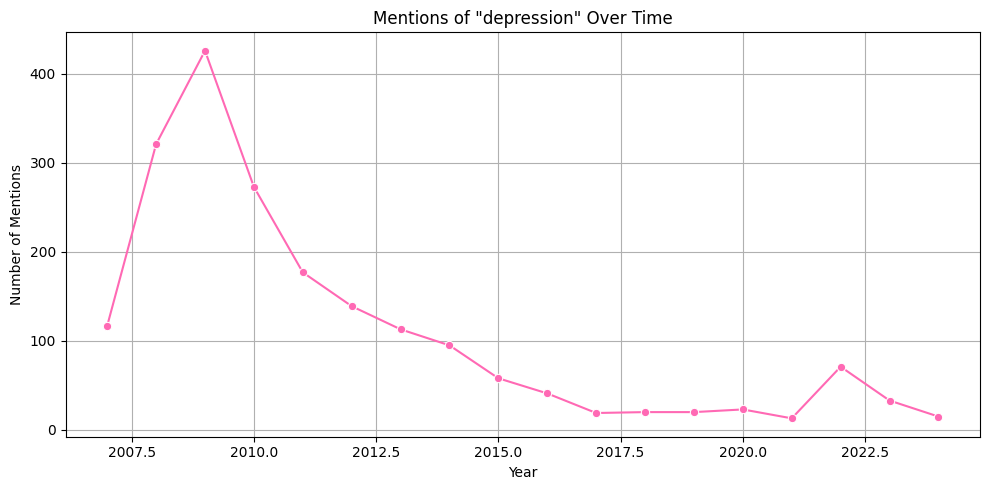

In [58]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=depression_trend, x='year', y='count', marker='o', color='hotpink')
plt.title('Mentions of "depression" Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Mentions')
plt.grid(True)
plt.tight_layout()
plt.show()

### Prevelence of 'pain' Aspect Over Time

In [26]:
pain_df = df[df['aspects'].apply(lambda x: 'pain' in x)]

In [27]:
pain_df['year'] = pain_df['date'].dt.year
pain_trend = pain_df.groupby('year').size().reset_index(name='count')

<ipython-input-27-68333525c7a4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pain_df['year'] = pain_df['date'].dt.year


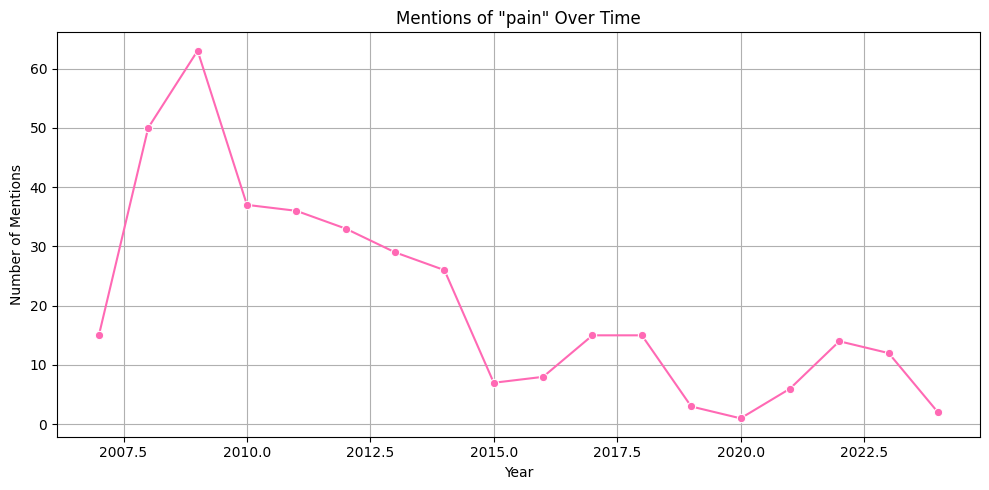

In [28]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=pain_trend, x='year', y='count', marker='o', color='hotpink')
plt.title('Mentions of "pain" Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Mentions')
plt.grid(True)
plt.tight_layout()
plt.show()

### Prevelence of 'weight' Aspect Over Time

In [29]:
weight_df = df[df['aspects'].apply(lambda x: 'weight' in x)]

In [30]:
weight_df['year'] = weight_df['date'].dt.year
weight_trend = weight_df.groupby('year').size().reset_index(name='count')

<ipython-input-30-3da489fd0860>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weight_df['year'] = weight_df['date'].dt.year


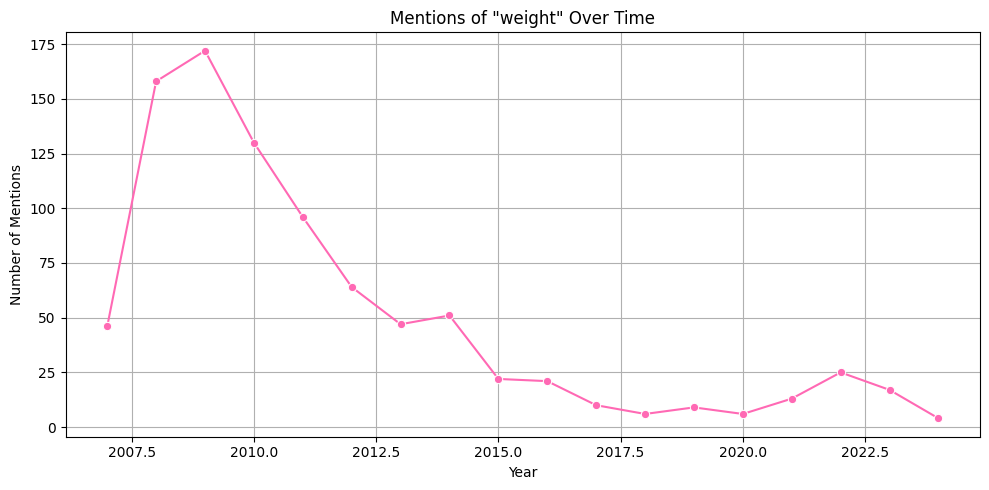

In [31]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=weight_trend, x='year', y='count', marker='o', color='hotpink')
plt.title('Mentions of "weight" Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Mentions')
plt.grid(True)
plt.tight_layout()
plt.show()